# Seasonal Agriculture Performance Analysis

**Role:** Data Analyst Intern  
**Objective:** Explore how season, weather, farm inputs and irrigation relate to agricultural performance.

I am using Python for the analysis and keeping the steps fairly simple so that the work is easy to follow and reproduce.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats


In [2]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 4000
Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
# Quick numerical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [5]:
# Summary of text/categorical columns
df.describe(include="object").T

C:\Users\neera\AppData\Local\Temp\ipykernel_23684\4248153904.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
Farm_ID,4000,4000,SF10001,1
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


In [6]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values found.")
else:
    missing_pct = (missing / len(df) * 100).round(2)
    display(pd.DataFrame({
        "Missing_Count": missing,
        "Missing_Pct": missing_pct
    }))

,Missing_Count,Missing_Pct
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [7]:
# Check for duplicate records
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Farm_ID values:", df["Farm_ID"].duplicated().sum())

Duplicate rows: 0
Duplicate Farm_ID values: 0


In [8]:
df_clean = df.drop_duplicates().copy()

print("Rows after removing exact duplicate rows:", len(df_clean))

Rows after removing exact duplicate rows: 4000


In [ ]:
# main categorical fields
for col in ["Season", "Crop", "State", "Irrigation_Method"]:
    print("\n", col)
    print(df_clean[col].value_counts())


 Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

 Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

 State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

 Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [10]:
# Keep a consistent order for the seasonal charts
season_order = [s for s in ["Kharif", "Rabi", "Zaid"] if s in df_clean["Season"].unique()]

# If the dataset uses different season names, use their existing order instead.
if not season_order:
    season_order = list(df_clean["Season"].dropna().unique())

season_order

['Kharif', 'Rabi', 'Zaid']

how many records belong to each season and how crops are distributed across seasons.

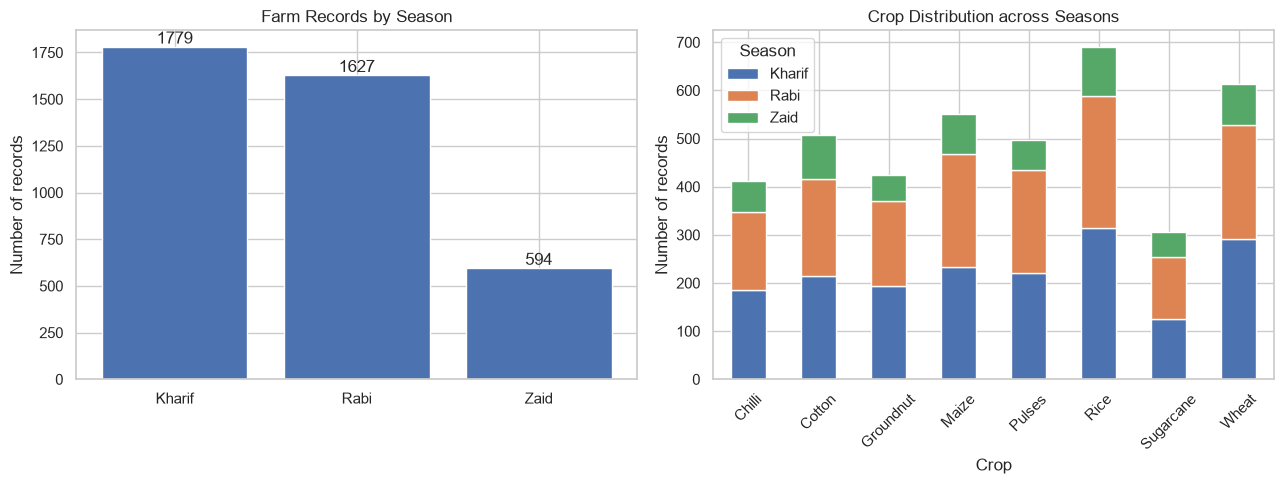

In [11]:
season_counts = df_clean["Season"].value_counts().reindex(season_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(season_counts.index, season_counts.values)
axes[0].set_title("Farm Records by Season")
axes[0].set_ylabel("Number of records")

for i, value in enumerate(season_counts.values):
    axes[0].text(i, value, str(value), ha="center", va="bottom")

crop_season = pd.crosstab(df_clean["Crop"], df_clean["Season"])
crop_season = crop_season.reindex(columns=season_order)

crop_season.plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Crop Distribution across Seasons")
axes[1].set_ylabel("Number of records")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

To compare rainfall, temperature, humidity and sunlight. 

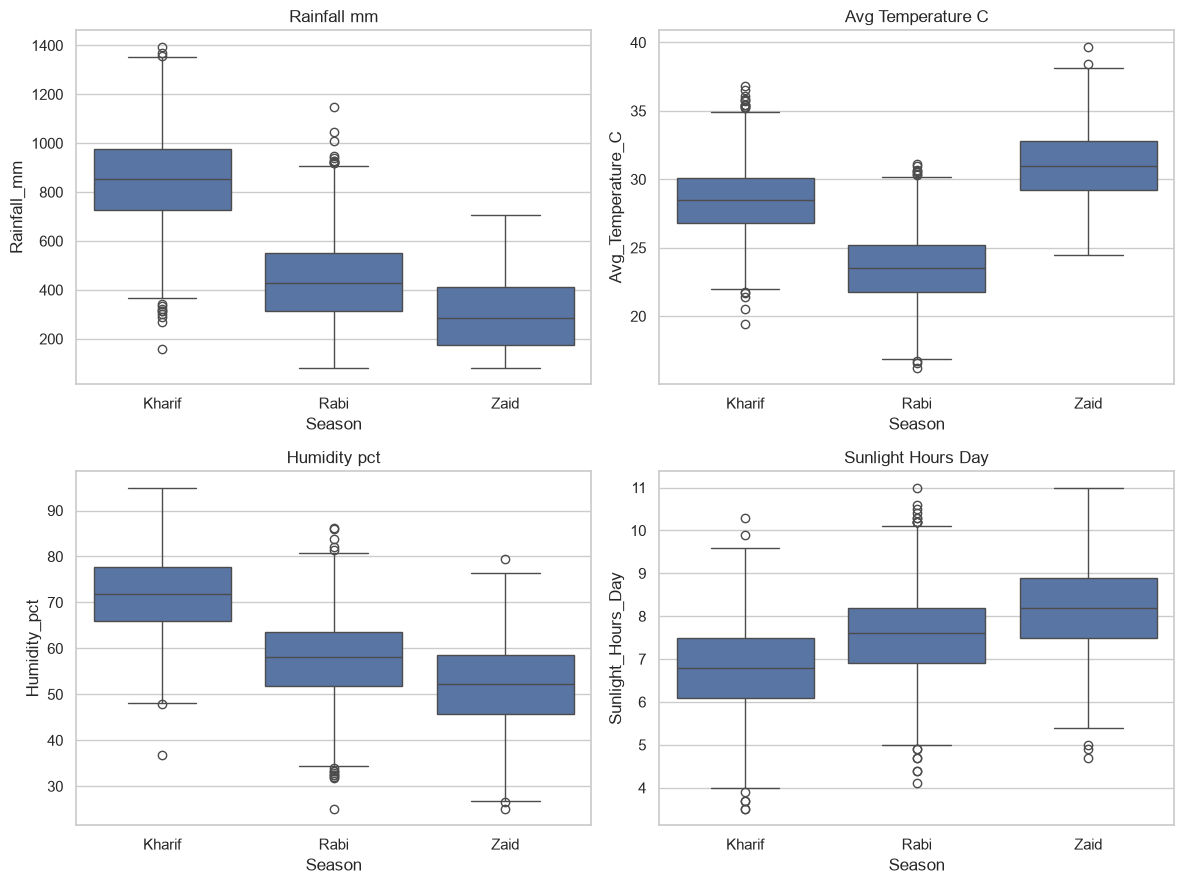

In [12]:
weather_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, col in zip(axes, weather_cols):
    sns.boxplot(data=df_clean, x="Season", y=col, order=season_order, ax=ax)
    ax.set_title(col.replace("_", " "))

plt.tight_layout()
plt.show()

In [ ]:
weather_summary = (
    df_clean.groupby("Season", observed=True)[weather_cols]
    .mean()
    .reindex(season_order)
    .round(2)
)

weather_summary

Yield is a better measure for comparing farm productivity because farm areas can be different.

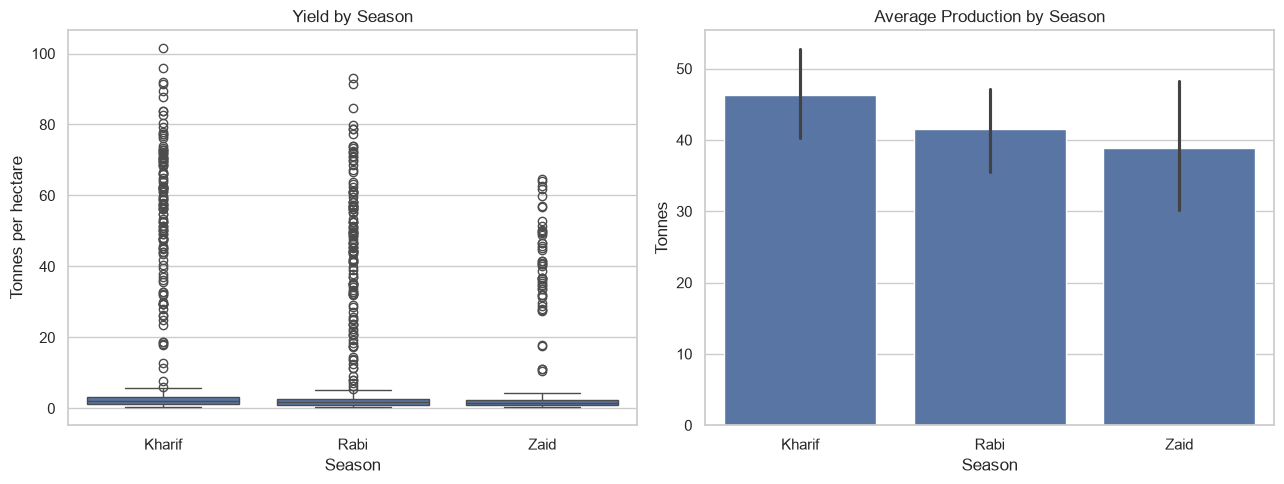

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Yield_Tonnes_Ha",
    order=season_order,
    ax=axes[0]
)
axes[0].set_title("Yield by Season")
axes[0].set_ylabel("Tonnes per hectare")

sns.barplot(
    data=df_clean,
    x="Season",
    y="Production_Tonnes",
    order=season_order,
    estimator="mean",
    ax=axes[1]
)
axes[1].set_title("Average Production by Season")
axes[1].set_ylabel("Tonnes")

plt.tight_layout()
plt.show()

In [14]:
yield_summary = (
    df_clean.groupby("Season", observed=True)["Yield_Tonnes_Ha"]
    .agg(["mean", "median", "std", "min", "max"])
    .reindex(season_order)
    .round(2)
)

yield_summary

,mean,median,std,min,max
Season,,,,,
Kharif,5.64,1.95,14.42,0.3,101.44
Rabi,5.08,1.66,12.83,0.3,93.13
Zaid,4.67,1.45,11.32,0.3,64.76


checking the cost, revenue and profit together rather than looking at profit.

In [ ]:
economic_cols = [
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
]

economic_summary = (
    df_clean.groupby("Season", observed=True)[economic_cols]
    .mean()
    .reindex(season_order)
    .round(2)
)

economic_summary

,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,
Kharif,531804.41,710719.06,178914.65
Rabi,513836.58,601526.05,87689.47
Zaid,543976.73,519171.90,-24804.82


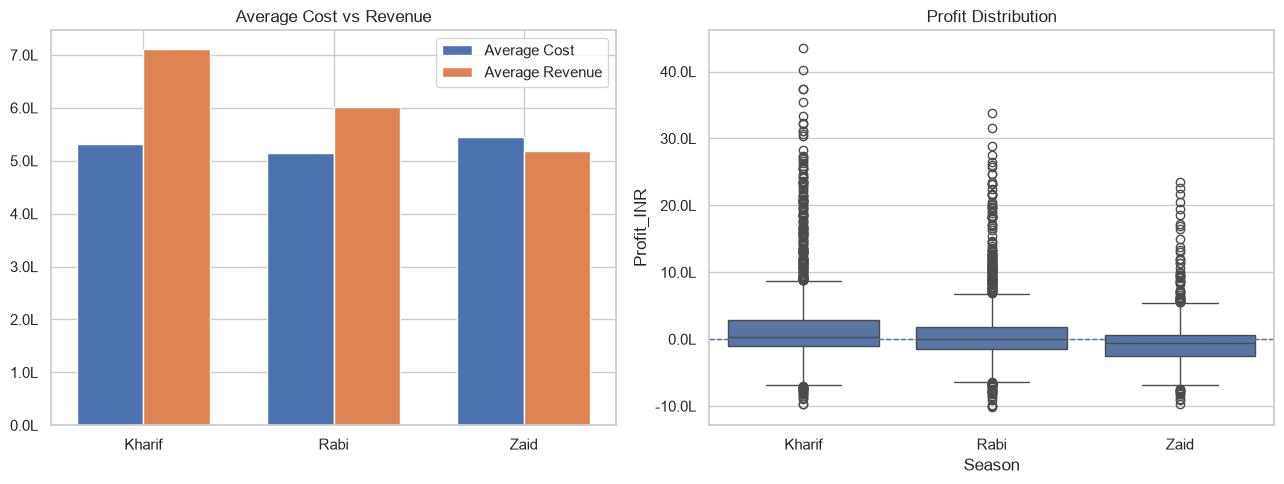

In [17]:
cost = (
    df_clean.groupby("Season", observed=True)["Total_Cost_INR"]
    .mean()
    .reindex(season_order)
)

revenue = (
    df_clean.groupby("Season", observed=True)["Revenue_INR"]
    .mean()
    .reindex(season_order)
)

x = np.arange(len(season_order))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(x - width / 2, cost, width, label="Average Cost")
axes[0].bar(x + width / 2, revenue, width, label="Average Revenue")
axes[0].set_xticks(x)
axes[0].set_xticklabels(season_order)
axes[0].set_title("Average Cost vs Revenue")
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda value, _: f"{value/1e5:.1f}L")
)

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Profit_INR",
    order=season_order,
    ax=axes[1]
)
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].set_title("Profit Distribution")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda value, _: f"{value/1e5:.1f}L")
)

plt.tight_layout()
plt.show()

In [18]:
# How many farms are making a loss?
loss_pct = (
    df_clean.groupby("Season", observed=True)["Profit_INR"]
    .apply(lambda x: (x < 0).mean() * 100)
    .reindex(season_order)
    .round(1)
)

loss_pct

Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Profit_INR, dtype: float64

Water, fertilizer and pesticide use. Water efficiency is included because high production of mean efficient resource use.

In [19]:
resource_cols = [
    "Water_Used_m3",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_Efficiency_t_per_1000m3"
]

resource_summary = (
    df_clean.groupby("Season", observed=True)[resource_cols]
    .mean()
    .reindex(season_order)
    .round(2)
)

resource_summary

,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,6102.20,187.08,5.08,5.89
Rabi,5846.99,185.41,5.02,5.19
Zaid,6419.89,184.64,5.17,4.41


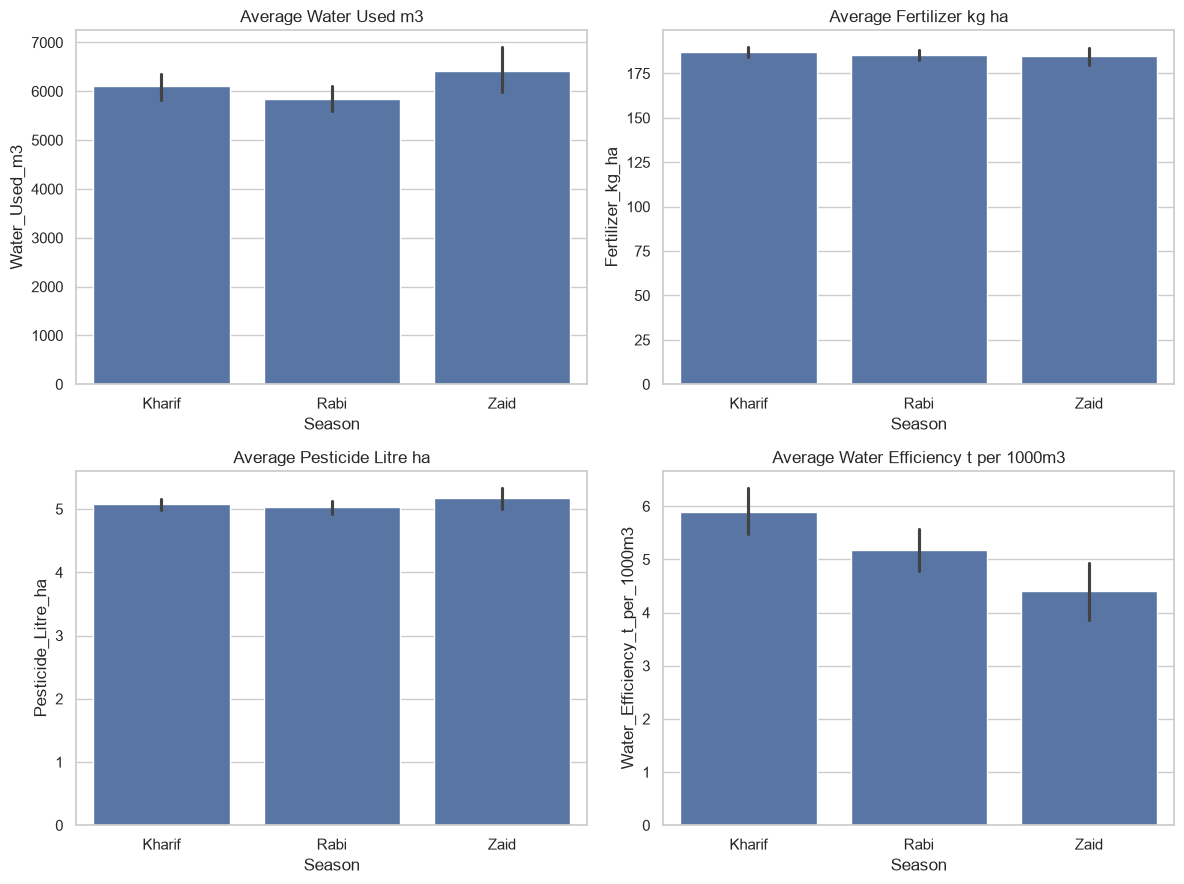

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, col in zip(axes, resource_cols):
    sns.barplot(
        data=df_clean,
        x="Season",
        y=col,
        order=season_order,
        estimator="mean",
        ax=ax
    )
    ax.set_title("Average " + col.replace("_", " "))

plt.tight_layout()
plt.show()

check the preferred irrigation method changes between seasons.

In [21]:
irrigation_share = pd.crosstab(
    df_clean["Season"],
    df_clean["Irrigation_Method"],
    normalize="index"
) * 100

irrigation_share = irrigation_share.reindex(season_order).round(1)
irrigation_share

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2




Correlation is used here as a first screening step. It shows association, not causation, so the results should not be treated as proof that one variable causes another.

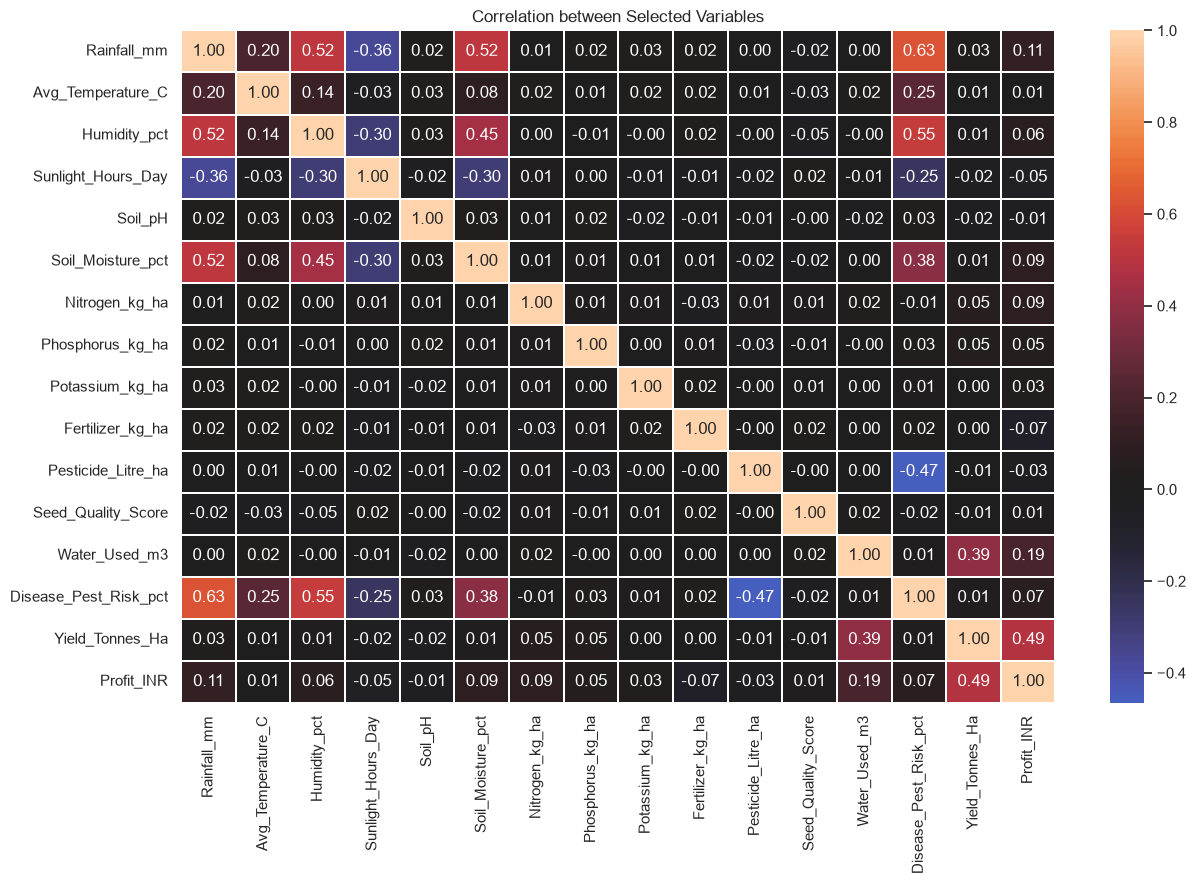

In [23]:
corr_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Water_Used_m3",
    "Disease_Pest_Risk_pct",
    "Yield_Tonnes_Ha",
    "Profit_INR"
]

corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(13, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    linewidths=0.3
)
plt.title("Correlation between Selected Variables")
plt.tight_layout()
plt.show()

In [24]:
yield_corr = (
    corr_matrix["Yield_Tonnes_Ha"]
    .drop("Yield_Tonnes_Ha")
    .sort_values(key=abs, ascending=False)
)

profit_corr = (
    corr_matrix["Profit_INR"]
    .drop("Profit_INR")
    .sort_values(key=abs, ascending=False)
)

print("Variables most correlated with Yield:")
display(yield_corr.head(6).to_frame("Correlation"))

print("Variables most correlated with Profit:")
display(profit_corr.head(6).to_frame("Correlation"))

Variables most correlated with Yield:


,Correlation
Profit_INR,0.489822
Water_Used_m3,0.388653
Nitrogen_kg_ha,0.053867
Phosphorus_kg_ha,0.047821
Rainfall_mm,0.030853
Soil_pH,-0.020664


Variables most correlated with Profit:


,Correlation
Yield_Tonnes_Ha,0.489822
Water_Used_m3,0.190278
Rainfall_mm,0.108104
Soil_Moisture_pct,0.091757
Nitrogen_kg_ha,0.085016
Fertilizer_kg_ha,-0.073542


In [25]:
# Season-level averages can hide differences between crops or states, so I am using pivot tables for a more detailed comparison.
crop_season_yield = (
    df_clean.pivot_table(
        values="Yield_Tonnes_Ha",
        index="Crop",
        columns="Season",
        aggfunc="mean",
        observed=True
    )
    .reindex(columns=season_order)
    .round(2)
)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


In [26]:
state_season_profit = (
    df_clean.pivot_table(
        values="Profit_INR",
        index="State",
        columns="Season",
        aggfunc="mean",
        observed=True
    )
    .reindex(columns=season_order)
    .round(0)
)

state_season_profit

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


In [27]:
# Average disease/pest risk by season
risk_summary = (
    df_clean.groupby("Season", observed=True)["Disease_Pest_Risk_pct"]
    .mean()
    .reindex(season_order)
    .round(2)
)

risk_summary

Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64